In [ ]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

Static Tomasulo

In [ ]:
class StaticTomasulo:
    def __init__(self, cost_coefficients, arrival_rates, total_cost, k):
        """
        Initialize the Tomasulo algorithm with cost allocation model

        Parameters:
        - cost_coefficients: List of cost coefficients [a1, a2, a3, a4] for each functional unit
        - arrival_rates: List of arrival rates [λ1, λ2, λ3, λ4] for each instruction type
        - total_cost: Fixed total cost C
        - k: Instructions issued per cycle
        """
        self.a = np.array(cost_coefficients)
        self.lambdas = np.array(arrival_rates)
        self.C = total_cost
        self.k = k

    def objective_function(self, mus):
        """
        Objective function to minimize the average waiting time of instructions

        Parameters:
        - mus: Array of service rates [μ1, μ2, μ3, μ4] for each functional unit

        Returns:
        - Total weighted average waiting time
        """
        # Calculate utilization rates
        rhos = self.lambdas / mus

        # Calculate waiting times for each functional unit, adding a small epsilon to avoid division by zero
        W = 1/mus + rhos / (2 * mus * (1 - rhos + 1e-10))

        # Weighted sum of waiting times
        return np.sum(self.lambdas * W)

    def solve_optimal_allocation(self):
        """
        Solve the optimization problem to find optimal service rates μi

        Returns:
        - Dictionary containing optimization results
        """

        # Better initial guess: distribute μ proportional to λ/a
        initial_mus = (self.C * self.lambdas / self.a) / np.sum(self.lambdas / self.a)

        # Cost constraint
        constraint = {'type': 'eq', 'fun': lambda mus: np.sum(self.a * mus) - self.C}

        # Bounds (μ_i > λ_i + small epsilon)
        bounds = [(self.lambdas[i] + 1e-6, None) for i in range(len(self.lambdas))]

        # Solve the optimization problem
        result = minimize(
            self.objective_function,
            initial_mus,
            method='SLSQP',
            bounds=bounds,
            constraints=[constraint],  # Using the cost constraint
            options={'maxiter': 1000, 'ftol': 1e-8}
        )

        if not result.success:
            # Try relaxing constraints if first attempt fails
            constraint = {'type': 'ineq', 'fun': lambda mus: self.C - np.sum(self.a * mus)}  # Cost constraint (relaxed)
            result = minimize(
                self.objective_function,
                initial_mus,
                method='SLSQP',
                bounds=bounds,
                constraints=[constraint],  # Using the relaxed cost constraint
                options={'maxiter': 2000, 'ftol': 1e-6, 'eps': 1e-3}
            )
            if not result.success:
                raise ValueError(f"Optimization failed after retry: {result.message}")

        optimal_mus = result.x
        optimal_rhos = self.lambdas / optimal_mus
        optimal_W = (1/optimal_mus + optimal_rhos / (2 * optimal_mus * (1 - optimal_rhos + 1e-10))) * self.k
        total_W = np.sum(self.lambdas * optimal_W) / np.sum(self.lambdas) # Total average waiting time

        # Calculate cost allocation percentages
        costs = self.a * optimal_mus
        cost_percentages = costs / np.sum(costs) * 100

        return {
            'optimal_mus': optimal_mus,
            'optimal_rhos': optimal_rhos,
            'waiting_times': optimal_W,
            'total_avg_waiting_time': total_W,
            'cost_allocation': costs,
            'cost_percentages': cost_percentages,
            'success': result.success
        }



Dynamic Tomasulo

In [ ]:
class DynamicTomasulo:
    def __init__(self, cost_coefficients, initial_arrival_rates, total_cost, k):
        """
        Initialize dynamic optimization model

        Parameters:
        - cost_coefficients: List of cost coefficients [a1, a2, a3, a4]
        - initial_arrival_rates: Initial guess for arrival rates [λ1, λ2, λ3, λ4]
        - total_cost: Total budget C
        - k: Instructions issued per cycle
        """
        self.a = np.array(cost_coefficients, dtype=np.float64)
        self.initial_lambdas = np.array(initial_arrival_rates, dtype=np.float64)
        self.lambdas = np.array(initial_arrival_rates, dtype=np.float64)
        self.C = total_cost
        self.k = k

        # Dynamic tracking
        self.arrival_counts = np.zeros_like(initial_arrival_rates)
        self.window_size = 1000
        self.cycle_count = 0
        self.optimization_history = []
        self.ema_alpha = 0.2
        self.last_mus = None

        # Instruction type mapping
        self.type_map = {'INT_ADD':0, 'FP_ADD':1, 'FP_MUL':2, 'MEM':3}

        # Initial optimization
        self._optimize()

    def _optimize(self):
        """Internal optimization routine called periodically"""
        if np.sum(self.arrival_counts) > 0:
            new_rates = self.arrival_counts / self.window_size
            self.lambdas = self.ema_alpha * new_rates + (1 - self.ema_alpha) * self.lambdas

        initial_mus = (self.last_mus if self.last_mus is not None
                      else (self.C * self.lambdas / self.a) / np.sum(self.lambdas / self.a))
        initial_mus = np.maximum(initial_mus, self.lambdas * 1.1)

        constraints = [
            {'type': 'eq', 'fun': lambda mus: np.sum(self.a * mus) - self.C},
            *[{'type': 'ineq', 'fun': lambda mus, i=i: mus[i] - self.lambdas[i] * 1.01}
              for i in range(len(self.lambdas))]
        ]

        result = minimize(
            self._objective_function,
            initial_mus,
            method='SLSQP',
            constraints=constraints,
            options={'maxiter': 1000, 'ftol': 1e-6}
        )

        if not result.success:
            raise ValueError(f"Optimization failed: {result.message}")

        self.last_mus = result.x
        self.arrival_counts[:] = 0

        optimal_rhos = self.lambdas / self.last_mus
        W = (1/self.last_mus + optimal_rhos/(2*self.last_mus*(1-optimal_rhos + 1e-6))) * self.k
        total_W = np.sum(self.lambdas * W) / np.sum(self.lambdas)

        self.optimization_history.append({
            'cycle': self.cycle_count,
            'mus': self.last_mus,
            'wait_time': total_W,
            'arrival_rates': self.lambdas.copy()
        })

    def _objective_function(self, mus):
        """Objective function for dynamic optimization"""
        mus = np.maximum(mus, self.lambdas * 1.01)
        rhos = self.lambdas / mus
        W = (1/mus + rhos / (2 * mus * (1 - rhos + 1e-6))) * self.k  # Include k here
        return np.sum(self.lambdas * W)

    def log_instruction(self, inst_type):
        """Process a single instruction and trigger optimization when needed"""
        if inst_type not in self.type_map:
            raise ValueError(f"Unknown instruction type: {inst_type}")

        idx = self.type_map[inst_type]
        self.arrival_counts[idx] += 1
        self.cycle_count += 1

        if self.cycle_count % self.window_size == 0:
            self._optimize()

    def get_current_allocation(self):
        """Get current allocation after optimization"""
        if not self.optimization_history:
            self._optimize()

        latest = self.optimization_history[-1]
        costs = self.a * latest['mus']
        cost_percentages = costs / np.sum(costs) * 100

        W = (1/latest['mus'] +
            (latest['arrival_rates']/latest['mus']) /
            (2*latest['mus']*(1 - latest['arrival_rates']/latest['mus'] + 1e-6))) * self.k

        return {
            'optimal_mus': latest['mus'],
            'optimal_rhos': latest['arrival_rates'] / latest['mus'],
            'waiting_times': W,
            'total_avg_waiting_time': latest['wait_time'],
            'cost_allocation': costs,
            'cost_percentages': cost_percentages
        }

    def plot_optimization_history(self):
        """Plot optimization history"""
        if not self.optimization_history:
            print("No optimization history to plot")
            return

        cycles = [entry['cycle'] for entry in self.optimization_history]
        mus = np.array([entry['mus'] for entry in self.optimization_history])

        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        for i in range(mus.shape[1]):
            plt.plot(cycles, mus[:, i], label=f'μ{i+1}')
        plt.xlabel('Clock Cycle')
        plt.ylabel('Service Rate (μ)')
        plt.legend()
        plt.title('Service Rate Adaptation')

        plt.subplot(1, 2, 2)
        wait_times = [entry['wait_time'] for entry in self.optimization_history]
        plt.plot(cycles, wait_times, 'r-')
        plt.xlabel('Clock Cycle')
        plt.ylabel('Avg Wait Time (ns)')
        plt.title('Waiting Time Trend')

        plt.tight_layout()
        plt.show()

Print Function and Implementation

In [ ]:
def print_results(num, results, dynamic=False):
    title = f"Results for Example {num} ({'Dynamic' if dynamic else 'Static'})"
    print("\n" + title)
    print("=" * len(title))
    print("Cost Allocation:", np.round(results['cost_allocation'], 2))
    print("Service Rates (μi):", np.round(results['optimal_mus'], 2))
    print("Avg Waiting Time:", np.round(results['total_avg_waiting_time'], 4), "ns")
    print("Utilization (ρi):", np.round(results['optimal_rhos'], 4))
    print("Cost % Allocation:", np.round(results['cost_percentages'], 2), "%")

def run_example(num, params, dynamic=False):
    if dynamic:
        print(f"\nDYNAMIC OPTIMIZATION - EXAMPLE {num}")
        print("=" * 50)

        tomasulo = DynamicTomasulo(
            cost_coefficients=params['cost_coeffs'],
            initial_arrival_rates=params['arrival_rates'],
            total_cost=params['total_cost'],
            k=params['k']
        )

        # Generate instruction stream
        instruction_types = list(tomasulo.type_map.keys())
        instructions = []
        for i, rate in enumerate(params['arrival_rates']):
            instructions.extend([instruction_types[i]] * np.random.poisson(rate * 5000))
        np.random.shuffle(instructions)

        # Process instructions
        for inst in instructions:
            tomasulo.log_instruction(inst)

        # Ensure final optimization
        if tomasulo.cycle_count % tomasulo.window_size != 0:
            tomasulo._optimize()

        # Plot and print results
        tomasulo.plot_optimization_history()
        results = tomasulo.get_current_allocation()
    else:
        print(f"\nSTATIC OPTIMIZATION - EXAMPLE {num}")
        print("=" * 50)

        tomasulo = StaticTomasulo(
            cost_coefficients=params['cost_coeffs'],
            arrival_rates=params['arrival_rates'],
            total_cost=params['total_cost'],
            k=params['k']
        )
        results = tomasulo.solve_optimal_allocation()

    print_results(num, results, dynamic)
    return results

Examples from Research Paper

TOMASULO ALGORITHM OPTIMIZATION DEMONSTRATION

STATIC OPTIMIZATION - EXAMPLE 1

Results for Example 1 (Static)
Cost Allocation: [  6.9   33.68 145.04  14.38]
Service Rates (μi): [1.38 1.12 0.73 1.44]
Avg Waiting Time: 1.4323 ns
Utilization (ρi): [0.0725 0.2672 0.5516 0.1391]
Cost % Allocation: [ 3.45 16.84 72.52  7.19] %

DYNAMIC OPTIMIZATION - EXAMPLE 1


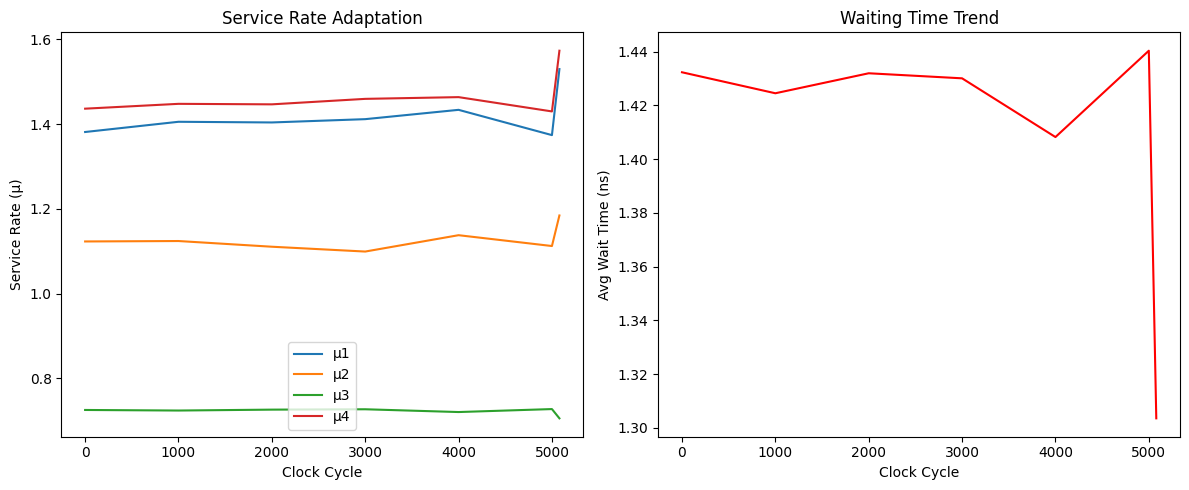


Results for Example 1 (Dynamic)
Cost Allocation: [  7.65  35.53 141.1   15.73]
Service Rates (μi): [1.53 1.18 0.71 1.57]
Avg Waiting Time: 1.3035 ns
Utilization (ρi): [0.0536 0.2045 0.4653 0.104 ]
Cost % Allocation: [ 3.82 17.76 70.55  7.86] %

COMPARISON:
Metric                         | Static          | Dynamic        
------------------------------------------------------------
total_avg_waiting_time         | 1.4323          | 1.3035         
cost_allocation                | [  6.8993  33.678  145.0409  14.3818] | [  7.6479  35.5266 141.0955  15.73  ]



STATIC OPTIMIZATION - EXAMPLE 2

Results for Example 2 (Static)
Cost Allocation: [ 11.76  96.74 370.39  21.12]
Service Rates (μi): [2.35 3.22 1.85 2.11]
Avg Waiting Time: 2.0265 ns
Utilization (ρi): [0.085  0.4032 0.648  0.1421]
Cost % Allocation: [ 2.35 19.35 74.08  4.22] %

DYNAMIC OPTIMIZATION - EXAMPLE 2


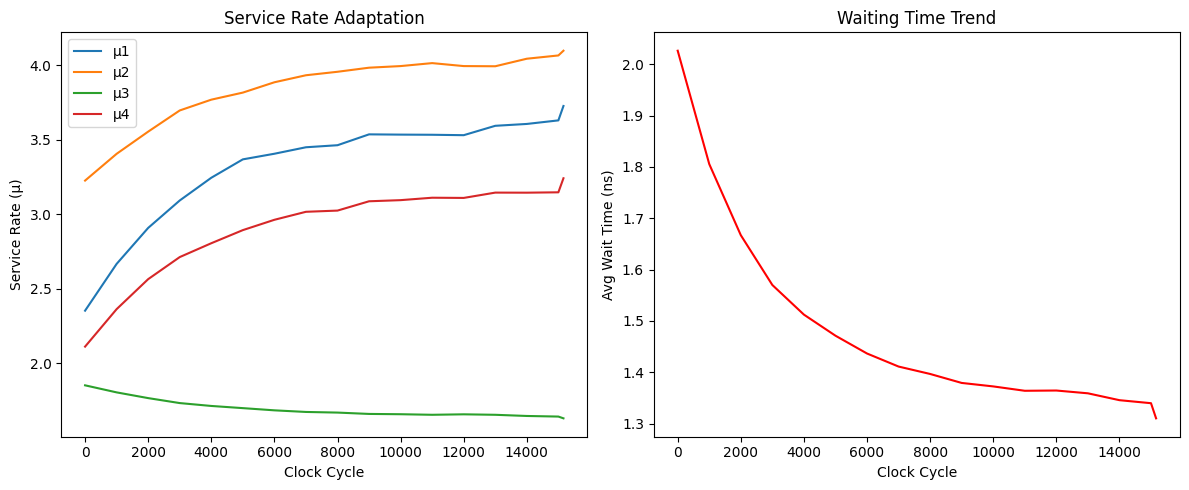


Results for Example 2 (Dynamic)
Cost Allocation: [ 18.63 122.89 326.08  32.41]
Service Rates (μi): [3.73 4.1  1.63 3.24]
Avg Waiting Time: 1.3103 ns
Utilization (ρi): [0.0162 0.0955 0.2146 0.0268]
Cost % Allocation: [ 3.73 24.58 65.22  6.48] %

COMPARISON:
Metric                         | Static          | Dynamic        
------------------------------------------------------------
total_avg_waiting_time         | 2.0265          | 1.3103         
cost_allocation                | [ 11.7602  96.7372 370.3852  21.1175] | [ 18.6275 122.8873 326.0775  32.4078]



STATIC OPTIMIZATION - EXAMPLE 3

Results for Example 3 (Static)
Cost Allocation: [ 33.27 176.15 429.02  61.56]
Service Rates (μi): [6.65 5.87 4.29 6.16]
Avg Waiting Time: 1.2361 ns
Utilization (ρi): [0.0751 0.2895 0.4662 0.13  ]
Cost % Allocation: [ 4.75 25.16 61.29  8.79] %

DYNAMIC OPTIMIZATION - EXAMPLE 3


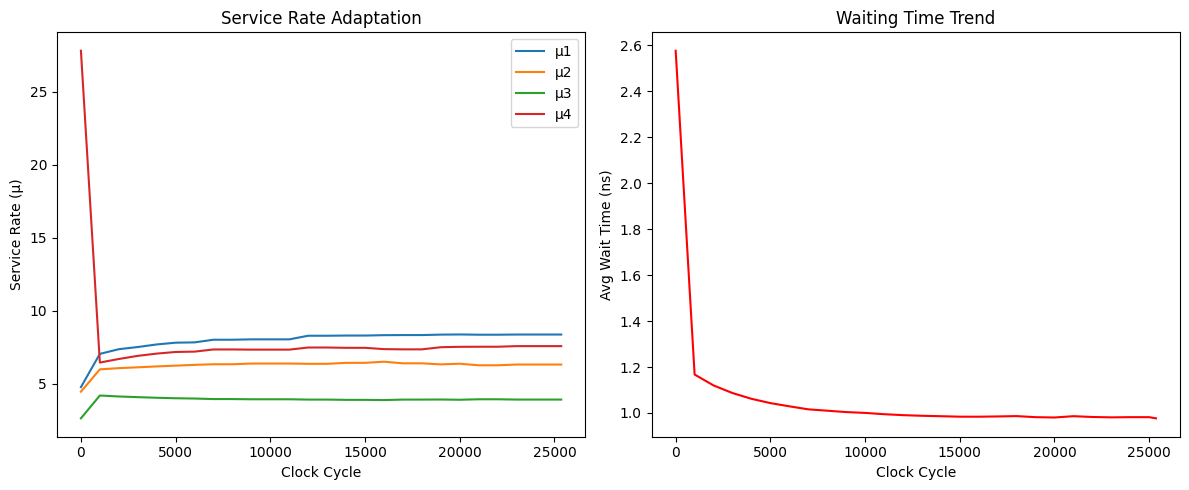


Results for Example 3 (Dynamic)
Cost Allocation: [ 41.89 189.72 392.56  75.84]
Service Rates (μi): [8.38 6.32 3.93 7.58]
Avg Waiting Time: 0.9767 ns
Utilization (ρi): [0.0107 0.047  0.0903 0.0189]
Cost % Allocation: [ 5.98 27.1  56.08 10.83] %

COMPARISON:
Metric                         | Static          | Dynamic        
------------------------------------------------------------
total_avg_waiting_time         | 1.2361          | 0.9767         
cost_allocation                | [ 33.2679 176.1533 429.0208  61.5579] | [ 41.8859 189.7214 392.5555  75.8372]




In [ ]:
# Example configurations
examples = {
    1: {
        'k': 1,
        'total_cost': 200,
        'arrival_rates': [0.1, 0.3, 0.4, 0.2],
        'cost_coeffs': [5, 30, 200, 10]
    },
    2: {
        'k': 3,
        'total_cost': 500,
        'arrival_rates': [0.2, 1.3, 1.2, 0.3],
        'cost_coeffs': [5, 30, 200, 10]
    },
    3: {
        'k': 5,
        'total_cost': 700,
        'arrival_rates': [0.5, 1.7, 2.0, 0.8],
        'cost_coeffs': [5, 30, 100, 10]
    }
}

# Run all examples
print("TOMASULO ALGORITHM OPTIMIZATION DEMONSTRATION")
print("="*60)
for num, params in examples.items():
    static_results = run_example(num, params, dynamic=False)
    dynamic_results = run_example(num, params, dynamic=True)

    # Comparison
    print("\nCOMPARISON:")
    print(f"{'Metric':<30} | {'Static':<15} | {'Dynamic':<15}")
    print("-" * 60)
    metrics = ['total_avg_waiting_time', 'cost_allocation']
    for m in metrics:
        static_val = np.round(static_results[m], 4)
        dynamic_val = np.round(dynamic_results[m], 4)
        print(f"{m:<30} | {str(static_val):<15} | {str(dynamic_val):<15}")
    print("\n" + "="*60 + "\n")